# Figure 5 — Steady-state observable convergence (all field values)

**Paper location:** Appendix D, Fig. 5.

## What this figure shows

An **accuracy check**: both filters recover the *exact* steady-state expectation
values for all three field values `h ∈ {0.5, 1.0, 1.5}` used in Ramusat & Savona.
The model has two physically independent non-trivial observables (`⟨σ_x⟩ = 0`
identically), shown as a 2×2 grid:

- **Rows:** phase estimation (top) vs deterministic Rodeo (bottom).
- **Columns:** `⟨σ_y⟩` (left) vs `⟨σ_z⟩` (right).
- **Colour:** one hue per field value `h`.

Each estimate (from the ratio readout `R_O / R_I`) converges to its distinct exact
NESS value (dashed) as the controlled-evolution depth `T` grows. At small depth the
ratio estimator swings strongly because the normalization readout `R_I` passes near
zero, so the connecting lines run off-scale there before settling — the vertical axes
are restricted to the convergence window.

## Model & comparison

| | |
|---|---|
| **Model** | single spin, `g = 1/2`; swept over `h ∈ {0.5, 1.0, 1.5}` |
| **Compared** | phase estimation vs deterministic Rodeo, both reading out via `R_O / R_I` |
| **Exact NESS** | `h=0.5`: `⟨σ_y⟩=2/3, ⟨σ_z⟩=-1/3`; the value shifts with `h` |
| **Purpose** | confirms both filters reach the *same* exact state — the resource advantage is quantified separately (Figs. 1, 2) |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../reproduce/core"))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from cost_compare import T0, deterministic_schedule
from qpe_filter import qpe_estimate
from rodeo_filter import rodeo_estimate
from model import steady_state, sy, sz

A_DET = 3.0
hs = [0.5, 1.0, 1.5]
hcol = {0.5: "#0072B2", 1.0: "#009E73", 1.5: "#D55E00"}
for h in hs:
    rho,_,_ = steady_state(h)
    print(f"h={h}: <sy>={np.trace(sy@rho).real:+.4f}, <sz>={np.trace(sz@rho).real:+.4f}")


h=0.5: <sy>=+0.6667, <sz>=-0.3333
h=1.0: <sy>=+0.4444, <sz>=-0.1111
h=1.5: <sy>=+0.3158, <sz>=-0.0526


### Compute estimates vs depth for each `h` and each filter

In [2]:
ts = range(1, 14)                      # QPE register sizes
qd = np.array([T0*(2**0)*0 + sum(T0*2**k for k in range(t)) for t in ts])  # QPE depth
# simpler: use qpe_depth
from cost_compare import qpe_depth
qd = np.array([qpe_depth(t) for t in ts])

ns = range(1, 26)                      # Rodeo cycle counts
rd_d = np.array([np.sum(np.abs(deterministic_schedule(n, A_DET))) for n in ns])

# precompute estimates: dict[(filter, obs, h)] = array
est = {}
for h in hs:
    for O, lbl in [(sy,"y"), (sz,"z")]:
        est[("qpe",lbl,h)] = np.array([qpe_estimate(h,t,T0,O) for t in ts])
        est[("rod",lbl,h)] = np.array([rodeo_estimate(h, deterministic_schedule(n,A_DET), O) for n in ns])
print("estimates computed for all (filter, observable, h)")

estimates computed for all (filter, observable, h)


### Figure (2×2 grid)

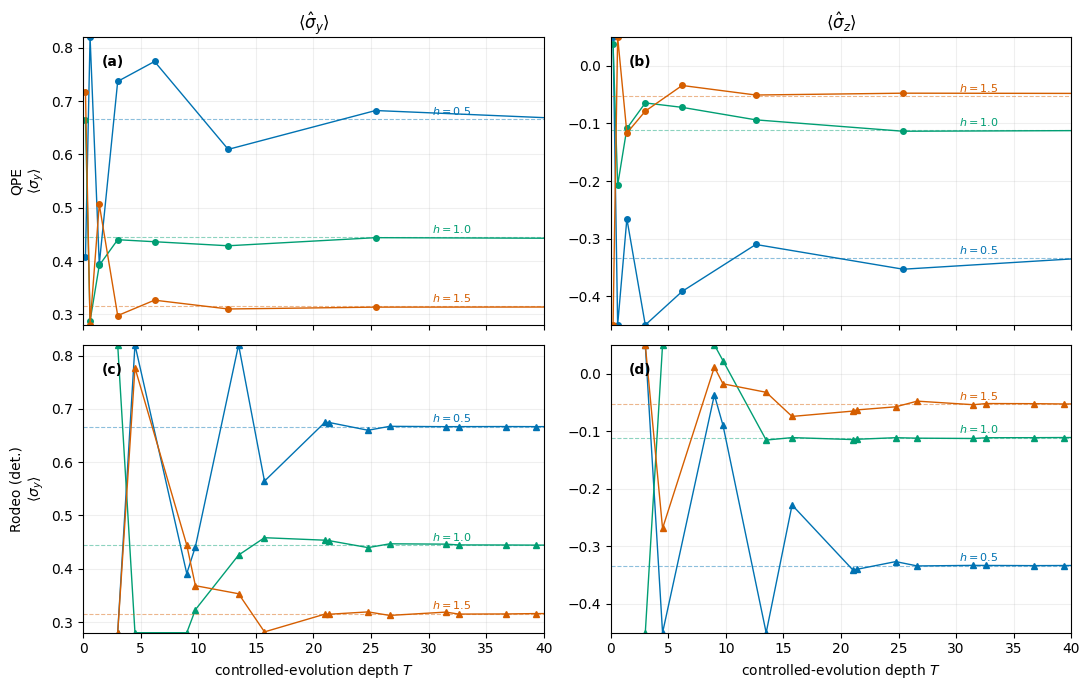

both filters converge to the exact NESS values for all h


In [3]:
XL = 40
ylims = {"y": (0.28, 0.82), "z": (-0.45, 0.05)}
exacts = {}
for h in hs:
    rho,_,_ = steady_state(h)
    exacts[("y",h)] = np.trace(sy@rho).real
    exacts[("z",h)] = np.trace(sz@rho).real

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
rowmark = {"qpe":"o", "rod":"^"}
rowlab  = {"qpe":"QPE", "rod":"Rodeo (det.)"}
for ri, filt in enumerate(["qpe","rod"]):
    xd = qd if filt=="qpe" else rd_d
    for ci, obs in enumerate(["y","z"]):
        ax = axes[ri][ci]
        ylo, yhi = ylims[obs]
        for h in hs:
            ex = exacts[(obs,h)]
            ax.axhline(ex, ls="--", color=hcol[h], alpha=0.45, lw=0.8)
            y = np.clip(est[(filt,obs,h)], ylo, yhi)
            ax.plot(xd, y, rowmark[filt]+"-", color=hcol[h], ms=4, lw=1.0)
            ax.annotate(f"$h={h}$", xy=(XL*0.8, ex), xytext=(0,3),
                        textcoords="offset points", fontsize=8, color=hcol[h],
                        ha="center", fontweight="bold")
        ax.set_xlim(0, XL); ax.set_ylim(ylo, yhi)
        if ci==0: ax.set_ylabel(rowlab[filt] + "\n" + r"$\langle\sigma_%s\rangle$" % obs, fontsize=10)
        if ri==0: ax.set_title(r"$\langle\hat\sigma_%s\rangle$" % obs)
        if ri==1: ax.set_xlabel(r"controlled-evolution depth $T$")
        ax.grid(alpha=0.2)
        tag = "(%s)" % "abcd"[ri*2+ci]
        ax.text(0.04, 0.90, tag, transform=ax.transAxes, fontweight="bold")
fig.tight_layout()
fig.savefig("fig_observables.pdf", bbox_inches="tight")
plt.show()
print("both filters converge to the exact NESS values for all h")